# Введение в 3D-данные и форматы файлов

Этот ноутбук задуман как **вводная практическая лекция**:

1. сначала мы разберём, **какие вообще бывают способы представления 3D-данных**;
2. затем посмотрим, **какие форматы реально используются для 3D-объектов, которые можно открыть и покрутить**;
3. после этого скачаем **конкретные OBJ / STL / PLY / glTF-примеры** и прямо в ноутбуке посмотрим:
   - какие файлы лежат в репозитории,
   - что у них внутри,
   - как они устроены,
   - и как их можно визуализировать.


# Часть A. Что такое 3D-объект

Когда люди говорят "у нас есть 3D-модель", они могут иметь в виду разные вещи.

В самом практическом смысле 3D-объект — это данные, которые позволяют описать **форму объекта в пространстве** и часто его **внешний вид**.

Обычно в 3D нас интересуют такие компоненты:

1. **Геометрия**  
   Где находится объект в пространстве.  
   Например: вершины, точки, треугольники, поверхность, объём.

2. **Внешний вид (appearance)**  
   Цвет, текстуры, материал, иногда отражения и прозрачность.

3. **Сцена**  
   Иногда файл хранит не просто один объект, а целую сцену:
   - несколько объектов,
   - их позиции,
   - камеры,
   - источники света,
   - анимации.

Поэтому один 3D-файл может быть очень простым ("вот список треугольников"),  
а другой — гораздо богаче ("вот целая сцена с текстурами и анимацией").


## Основные способы представления 3D-данных

### 1. Point cloud — облако точек
Это просто много точек в пространстве.

Каждая точка обычно имеет:
- координаты `x, y, z`,
- иногда цвет `r, g, b`,
- иногда нормаль,
- иногда другие атрибуты.

Такое представление хорошо подходит для:
- сканов,
- LiDAR,
- первичного результата реконструкции.

**Плюс:** просто получить.  
**Минус:** это ещё не полноценная "поверхность".

---

### 2. Mesh — полигональная сетка
Это самое классическое представление 3D-объекта.

Mesh обычно состоит из:
- **вершин** (`vertices`) — точек в 3D,
- **граней** (`faces`) — чаще всего треугольников, которые соединяют вершины,
- иногда **нормалей**,
- иногда **UV-координат** для текстур.

Именно mesh чаще всего открывают в Blender, играх, CAD, 3D-редакторах.

**Плюс:** стандартно, удобно визуализировать и редактировать.  
**Минус:** качественный mesh не всегда просто получить из сырых данных.

---

### 3. Voxels — 3D-пиксели
Пространство делится на маленькие кубики, и для каждого кубика хранится информация:
- пусто там или нет,
- плотность,
- цвет и т. д.

Это похоже на Minecraft, только обычно с более мелкой сеткой.

**Плюс:** интуитивно понятно.  
**Минус:** память растёт очень быстро.

---

### 4. Implicit representations
Вместо явного списка точек или треугольников хранится **функция**, которая говорит:
- находится ли точка внутри объекта,
- каково расстояние до поверхности,
- какова плотность и цвет в этой точке.

Сюда относятся:
- SDF,
- occupancy fields,
- NeRF,
- другие neural fields.

Это уже более современное представление.

**Важно:** такое представление не всегда является "обычным файлом модели", который легко открыть в 3D viewer как OBJ.

---

### 5. Сценовые представления
Иногда нужно хранить не просто один объект, а целую сцену:
- иерархию объектов,
- материалы,
- текстуры,
- анимации,
- камеры.

Для этого используются более богатые форматы: например, glTF, FBX, USD.


## Что значит "настоящий 3D-файл, который можно открыть"

Для нашей практики нас интересуют именно такие форматы, которые дают **реальный 3D-объект**, который можно:
- скачать,
- открыть в Blender / MeshLab / online viewer / Colab,
- покрутить,
- обсудить.

Нас будут интересовать в первую очередь:

- **OBJ** — классический текстовый формат для mesh
- **MTL** — файл материалов, обычно идёт рядом с OBJ
- **STL** — простой формат треугольной поверхности, популярен в 3D-печати
- **PLY** — часто используется для point clouds и сканов, но умеет и mesh
- **glTF / GLB** — современный формат 3D-ассетов и сцен

Другие важные форматы:
- **FBX** — богатый индустриальный формат обмена
- **USD / USDZ** — более сценовый / production-ориентированный формат

При этом:
- **NeRF checkpoint / model weights**: это уже **не обычный 3D-объект**, а нейросеточное представление сцены


# Часть B. Практика: скачиваем конкретные файлы и смотрим, что внутри

Мы возьмём несколько учебных примеров:

1. **OBJ (простой куб)**  
2. **OBJ + MTL + texture**  
3. **STL (тот же куб)**  
4. **PLY (bunny)**  
5. **OBJ (cow)**  
6. **glTF (BoxTextured)**

Идея такая:
- сначала посмотреть на файл глазами человека,
- потом дать Python извлечь статистику,
- потом попробовать визуализировать.


In [11]:
!pip -q install trimesh plotly pygltflib pillow pandas numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.5/740.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.6 MB/s eta 0:00:00


In [13]:
from pathlib import Path
import json
import urllib.request
from pprint import pprint

import numpy as np
import pandas as pd
import trimesh
import plotly.graph_objects as go

BASE_DIR = Path("three_d_examples")
BASE_DIR.mkdir(exist_ok=True)

print("Рабочая папка:", BASE_DIR.resolve())


Рабочая папка: /content/three_d_examples


## Какие именно файлы мы будем скачивать

Ниже — словарь с примерами.  
Обрати внимание: некоторые форматы требуют **несколько связанных файлов**.

Например:
- `cube-tex.obj` ссылается на `cube.mtl`
- `cube.mtl` ссылается на `texture.png`
- `BoxTextured.gltf` ссылается на `.bin` и `.png`

Это важная практическая деталь:  
**3D-объект очень часто состоит не из одного файла, а из набора взаимосвязанных файлов.**

Данные:
- https://github.com/garykac/3d-cubes
- https://github.com/pyvista/vtk-data/blob/master/Data/bunny.ply
- https://github.com/alecjacobson/common-3d-test-models/tree/master/data
- https://github.com/KhronosGroup/glTF-Sample-Models/tree/master/2.0/BoxTextured/glTF

In [ ]:
EXAMPLES = {
    "obj_simple": {
        "folder": BASE_DIR / "obj_simple",
        "files": {
            "cube.obj": "https://raw.githubusercontent.com/garykac/3d-cubes/master/cube.obj",
        },
    },
    "obj_textured": {
        "folder": BASE_DIR / "obj_textured",
        "files": {
            "cube-tex.obj": "https://raw.githubusercontent.com/garykac/3d-cubes/master/cube-tex.obj",
            "cube.mtl": "https://raw.githubusercontent.com/garykac/3d-cubes/master/cube.mtl",
            "texture.png": "https://raw.githubusercontent.com/garykac/3d-cubes/master/texture.png",
        },
    },
    "stl_simple": {
        "folder": BASE_DIR / "stl_simple",
        "files": {
            "cube.stl": "https://raw.githubusercontent.com/garykac/3d-cubes/master/cube.stl",
        },
    },
    "ply_bunny": {
        "folder": BASE_DIR / "ply_bunny",
        "files": {
            "bunny.ply": "https://raw.githubusercontent.com/pyvista/vtk-data/master/Data/bunny.ply",
        },
    },
    "obj_cow": {
        "folder": BASE_DIR / "obj_cow",
        "files": {
            "cow.obj": "https://raw.githubusercontent.com/alecjacobson/common-3d-test-models/master/data/cow.obj",
        },
    },
    "gltf_box_textured": {
        "folder": BASE_DIR / "gltf_box_textured",
        "files": {
            "BoxTextured.gltf": "https://raw.githubusercontent.com/KhronosGroup/glTF-Sample-Models/master/2.0/BoxTextured/glTF/BoxTextured.gltf",
            "BoxTextured0.bin": "https://raw.githubusercontent.com/KhronosGroup/glTF-Sample-Models/master/2.0/BoxTextured/glTF/BoxTextured0.bin",
            "CesiumLogoFlat.png": "https://raw.githubusercontent.com/KhronosGroup/glTF-Sample-Models/master/2.0/BoxTextured/glTF/CesiumLogoFlat.png",
        },
    },
}


In [ ]:
def download_file(url: str, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, dst)
    return dst

for group_name, group in EXAMPLES.items():
    print(f"\n=== Скачиваем: {group_name} ===")
    folder = group["folder"]
    folder.mkdir(parents=True, exist_ok=True)
    for filename, url in group["files"].items():
        dst = folder / filename
        if not dst.exists():
            download_file(url, dst)
        print("OK:", dst)

print("\nГотово.")



=== Скачиваем: obj_simple ===
OK: three_d_examples/obj_simple/cube.obj

=== Скачиваем: obj_textured ===
OK: three_d_examples/obj_textured/cube-tex.obj
OK: three_d_examples/obj_textured/cube.mtl
OK: three_d_examples/obj_textured/texture.png

=== Скачиваем: stl_simple ===
OK: three_d_examples/stl_simple/cube.stl

=== Скачиваем: ply_bunny ===
OK: three_d_examples/ply_bunny/bunny.ply

=== Скачиваем: obj_cow ===
OK: three_d_examples/obj_cow/cow.obj

=== Скачиваем: gltf_box_textured ===
OK: three_d_examples/gltf_box_textured/BoxTextured.gltf
OK: three_d_examples/gltf_box_textured/BoxTextured0.bin
OK: three_d_examples/gltf_box_textured/CesiumLogoFlat.png

Готово.


In [ ]:
for group_name, group in EXAMPLES.items():
    print(f"\n[{group_name}] -> {group['folder']}")
    for p in sorted(group["folder"].iterdir()):
        print("  ", p.name, "-", p.stat().st_size, "bytes")



[obj_simple] -> three_d_examples/obj_simple
   cube.obj - 1560 bytes

[obj_textured] -> three_d_examples/obj_textured
   cube-tex.obj - 2382 bytes
   cube.mtl - 95 bytes
   texture.png - 294 bytes

[stl_simple] -> three_d_examples/stl_simple
   cube.stl - 2526 bytes

[ply_bunny] -> three_d_examples/ply_bunny
   bunny.ply - 3033235 bytes

[obj_cow] -> three_d_examples/obj_cow
   cow.obj - 180177 bytes

[gltf_box_textured] -> three_d_examples/gltf_box_textured
   BoxTextured.gltf - 3695 bytes
   BoxTextured0.bin - 840 bytes
   CesiumLogoFlat.png - 4333 bytes


# Полезные функции

Ниже — набор функций, которые пригодятся для анализа:

- посмотреть первые строки файла;
- быстро оценить, текстовый файл или бинарный;
- посчитать, сколько в OBJ вершин, UV, нормалей и граней;
- прочитать заголовок PLY;
- открыть glTF как JSON и посмотреть, на что он ссылается;
- построить простую 3D-визуализацию в Plotly.


In [ ]:
from pathlib import Path
import trimesh
import tempfile
import os

def is_probably_text(path: Path, blocksize: int = 512) -> bool:
    with open(path, "rb") as f:
        chunk = f.read(blocksize)
    if b"\x00" in chunk:
        return False
    try:
        chunk.decode("utf-8")
        return True
    except UnicodeDecodeError:
        return False


def preview_text(path: Path, n_lines: int = 25):
    print(f"--- preview: {path} ---")
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f):
            if i >= n_lines:
                print("... (обрезано)")
                break
            print(f"{i+1:02d}: {line.rstrip()}")


def obj_stats(path: Path):
    stats = {"v": 0, "vt": 0, "vn": 0, "f": 0, "mtllib": [], "usemtl": []}
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            s = line.strip()
            if s.startswith("v "):
                stats["v"] += 1
            elif s.startswith("vt "):
                stats["vt"] += 1
            elif s.startswith("vn "):
                stats["vn"] += 1
            elif s.startswith("f "):
                stats["f"] += 1
            elif s.startswith("mtllib "):
                stats["mtllib"].append(s.split(maxsplit=1)[1])
            elif s.startswith("usemtl "):
                stats["usemtl"].append(s.split(maxsplit=1)[1])
    return stats


def ply_header(path: Path, max_lines: int = 40):
    print(f"--- PLY header: {path} ---")
    with open(path, "rb") as f:
        raw = f.read(4096)
    text = raw.decode("utf-8", errors="replace")
    lines = text.splitlines()
    for i, line in enumerate(lines[:max_lines]):
        print(f"{i+1:02d}: {line}")
        if line.strip() == "end_header":
            break


def gltf_summary(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    summary = {
        "top_level_keys": list(data.keys()),
        "num_scenes": len(data.get("scenes", [])),
        "num_nodes": len(data.get("nodes", [])),
        "num_meshes": len(data.get("meshes", [])),
        "num_materials": len(data.get("materials", [])),
        "num_buffers": len(data.get("buffers", [])),
        "num_bufferViews": len(data.get("bufferViews", [])),
        "num_accessors": len(data.get("accessors", [])),
        "num_images": len(data.get("images", [])),
        "num_textures": len(data.get("textures", [])),
    }
    return data, summary

def load_trimesh_any(path):
    path = Path(path)

    # Для OBJ: удаляем inline-комментарии вида "... # comment"
    if path.suffix.lower() == ".obj":
        text = path.read_text(encoding="utf-8", errors="replace")

        cleaned_lines = []
        for line in text.splitlines():
            # убираем всё после #
            if "#" in line:
                line = line.split("#", 1)[0]
            line = line.strip()
            if line:
                cleaned_lines.append(line)

        cleaned_text = "\n".join(cleaned_lines) + "\n"

        with tempfile.NamedTemporaryFile(
            mode="w",
            suffix=".obj",
            delete=False,
            encoding="utf-8"
        ) as tmp:
            tmp.write(cleaned_text)
            tmp_path = tmp.name

        try:
            loaded = trimesh.load(tmp_path, force="mesh", process=False)
        finally:
            os.remove(tmp_path)

        return loaded

    # Для остальных форматов
    return trimesh.load(path, force="mesh", process=False)


def as_single_trimesh(obj):
    if isinstance(obj, trimesh.Trimesh):
        return obj

    if isinstance(obj, trimesh.Scene):
        meshes = [g for g in obj.geometry.values() if isinstance(g, trimesh.Trimesh)]
        if len(meshes) == 0:
            raise ValueError("В Scene нет ни одного Trimesh-объекта.")
        if len(meshes) == 1:
            return meshes[0]
        return trimesh.util.concatenate(meshes)

    raise TypeError(f"Неожиданный тип объекта: {type(obj)}")


def mesh_basic_stats(mesh):
    return {
        "vertices": len(mesh.vertices),
        "faces": len(mesh.faces),
        "bounds": mesh.bounds.tolist(),
        "is_watertight": bool(mesh.is_watertight),
        "is_winding_consistent": bool(mesh.is_winding_consistent),
        "extents": mesh.extents.tolist(),
    }

def plot_trimesh(mesh, title="3D mesh"):
    vertices = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.faces)

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                opacity=1.0,
            )
        ]
    )
    fig.update_layout(
        title=title,
        width=800,
        height=700,
        scene_aspectmode="data",
    )
    fig.show()


def plot_point_cloud(points, title="Point cloud"):
    points = np.asarray(points)
    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=points[:, 0],
                y=points[:, 1],
                z=points[:, 2],
                mode="markers",
                marker=dict(size=2),
            )
        ]
    )
    fig.update_layout(
        title=title,
        width=800,
        height=700,
        scene_aspectmode="data",
    )
    fig.show()


# 1. OBJ: самый понятный формат для начала

OBJ — хороший учебный формат, потому что он **текстовый**.  
Это значит, что его можно открыть и реально глазами увидеть структуру данных.

Обычно в OBJ встречаются такие строки:

- `v ...` — вершины
- `vt ...` — UV-координаты
- `vn ...` — нормали
- `f ...` — грани
- `mtllib ...` — ссылка на файл материалов
- `usemtl ...` — какой материал использовать

Начнём с самого простого куба.


In [ ]:
obj_simple_path = EXAMPLES["obj_simple"]["folder"] / "cube.obj"

print("Это текстовый файл?", is_probably_text(obj_simple_path))
preview_text(obj_simple_path, n_lines=100)


Это текстовый файл? True
--- preview: three_d_examples/obj_simple/cube.obj ---
01: # cube.obj
02: # Import into Blender with Y-forward, Z-up
03: #
04: # Vertices:                        Faces:
05: #      f-------g                          +-------+
06: #     /.      /|                         /.  5   /|  3 back
07: #    / .     / |                        / .     / |
08: #   e-------h  |                   2   +-------+ 1|
09: #   |  b . .|. c      z          right |  . . .|. +
10: #   | .     | /       | /y             | . 4   | /
11: #   |.      |/        |/               |.      |/
12: #   a-------d         +---- x          +-------+
13: #                                           6
14: #                                        bottom
15: 
16: g cube
17: 
18: # Vertices
19: v 0.0 0.0 0.0  # 1 a
20: v 0.0 1.0 0.0  # 2 b
21: v 1.0 1.0 0.0  # 3 c
22: v 1.0 0.0 0.0  # 4 d
23: v 0.0 0.0 1.0  # 5 e
24: v 0.0 1.0 1.0  # 6 f
25: v 1.0 1.0 1.0  # 7 g
26: v 1.0 0.0 1.0  # 8 h
27: 
28: # Normal v

In [ ]:
print("Статистика OBJ:")
pprint(obj_stats(obj_simple_path))


Статистика OBJ:
{'f': 12, 'mtllib': [], 'usemtl': [], 'v': 8, 'vn': 6, 'vt': 0}


In [ ]:
obj_simple_loaded = load_trimesh_any(obj_simple_path)
obj_simple_mesh = as_single_trimesh(obj_simple_loaded)

print("Тип после загрузки:", type(obj_simple_loaded))
print("Базовая статистика mesh:")
pprint(mesh_basic_stats(obj_simple_mesh))


Тип после загрузки: <class 'trimesh.base.Trimesh'>
Базовая статистика mesh:
{'bounds': [[0.0, 0.0, 0.0], [1.0, 1.0, 1.0]],
 'extents': [1.0, 1.0, 1.0],
 'faces': 12,
 'is_watertight': False,
 'is_winding_consistent': True,
 'vertices': 24}


In [ ]:
plot_trimesh(obj_simple_mesh, title="cube.obj — простой OBJ mesh")


### Что важно понять на этом примере

1. **OBJ хранит геометрию явно**  
   В файле прямо перечислены вершины и грани.

2. **Грани ссылаются на вершины по индексам**  
   То есть файл не дублирует координаты снова и снова, а говорит:
   "вот эта грань построена из вершин с такими индексами".

3. **OBJ сам по себе не обязан содержать текстуры**  
   Он может быть совсем простым — просто vertices + faces.


# 2. OBJ + MTL + текстура

Теперь посмотрим на более реалистичный случай:  
объект хранится **не в одном файле**, а как набор файлов:

- `.obj` — геометрия
- `.mtl` — материалы
- `.png` — текстура


На практике для корректного отображения текстур обычно нужны и соседние файлы.


In [ ]:
obj_textured_folder = EXAMPLES["obj_textured"]["folder"]
obj_textured_path = obj_textured_folder / "cube-tex.obj"
mtl_path = obj_textured_folder / "cube.mtl"
texture_path = obj_textured_folder / "texture.png"

print("OBJ preview:")
preview_text(obj_textured_path, n_lines=100)

print("\nMTL preview:")
preview_text(mtl_path, n_lines=60)


OBJ preview:
--- preview: three_d_examples/obj_textured/cube-tex.obj ---
01: # cube-tex.obj
02: # Import into Blender with Y-forward, Z-up
03: #
04: # Vertices:                        Faces:
05: #      f-------g                          +-------+
06: #     /.      /|                         /.  5   /|  3 back
07: #    / .     / |                        / .     / |
08: #   e-------h  |                   2   +-------+ 1|
09: #   |  b . .|. c      z          right |  . . .|. +
10: #   | .     | /       | /y             | . 4   | /
11: #   |.      |/        |/               |.      |/
12: #   a-------d         +---- x          +-------+
13: #                                           6
14: #                                        bottom
15: 
16: # Material defined in separate file.
17: mtllib cube.mtl
18: 
19: g cube
20: 
21: # Vertices
22: v 0.0 0.0 0.0  # 1 a
23: v 0.0 1.0 0.0  # 2 b
24: v 1.0 1.0 0.0  # 3 c
25: v 1.0 0.0 0.0  # 4 d
26: v 0.0 0.0 1.0  # 5 e
27: v 0.0 1.0 1.0  # 6 f
28: v

In [ ]:
print("Статистика текстурированного OBJ:")
pprint(obj_stats(obj_textured_path))
print("\nРазмер texture.png:", texture_path.stat().st_size, "bytes")


Статистика текстурированного OBJ:
{'f': 12,
 'mtllib': ['cube.mtl'],
 'usemtl': ['texture'],
 'v': 8,
 'vn': 6,
 'vt': 14}

Размер texture.png: 294 bytes


In [ ]:
obj_textured_loaded = load_trimesh_any(obj_textured_path)
obj_textured_mesh = as_single_trimesh(obj_textured_loaded)

print("Тип после загрузки:", type(obj_textured_loaded))
pprint(mesh_basic_stats(obj_textured_mesh))


Тип после загрузки: <class 'trimesh.base.Trimesh'>
{'bounds': [[0.0, 0.0, 0.0], [1.0, 1.0, 1.0]],
 'extents': [1.0, 1.0, 1.0],
 'faces': 12,
 'is_watertight': False,
 'is_winding_consistent': True,
 'vertices': 24}


In [ ]:
plot_trimesh(obj_textured_mesh, title="cube-tex.obj — геометрия OBJ (+ текстура лежит рядом)")


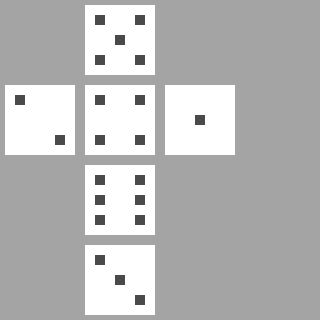

In [ ]:
from IPython.display import Image

Image(texture_path)

### Что здесь важно

1. **OBJ часто ссылается на MTL**
2. **MTL уже ссылается на текстуру**
3. Значит, "3D-модель" на диске часто состоит из нескольких файлов

То есть:
- геометрия живёт в OBJ,
- материалы — в MTL,
- текстура — в PNG/JPG.

Это один из самых важных практических моментов во всей теме 3D-файлов.


# 3. STL: минималистичный формат поверхности

STL — очень известный формат в 3D-печати и вообще в задачах, где важна **форма**, а не внешний вид.

Идея STL:
- модель представляется как набор **треугольников**;
- для каждого треугольника задаётся нормаль и три вершины.

Чего обычно нет в STL:
- нормальной поддержки текстур,
- богатых материалов,
- сцены,
- анимаций.

Поэтому STL — это чаще "чистая форма", а не полноценный красивый ассет.


In [ ]:
stl_path = EXAMPLES["stl_simple"]["folder"] / "cube.stl"

print("Это текстовый STL?", is_probably_text(stl_path))
if is_probably_text(stl_path):
    preview_text(stl_path, n_lines=100)
else:
    print("Файл, скорее всего, бинарный. Это нормально для STL.")


Это текстовый STL? True
--- preview: three_d_examples/stl_simple/cube.stl ---
01: ;; cube.stl
02: ;; Import into Blender with Y-forward, Z-up
03: ;;
04: ;; Vertices:                        Faces:
05: ;;      f-------g                          +-------+
06: ;;     /.      /|                         /.  5   /|  3 back
07: ;;    / .     / |                        / .     / |
08: ;;   e-------h  |                   2   +-------+ 1|
09: ;;   |  b . .|. c      z          right |  . . .|. +
10: ;;   | .     | /       | /y             | . 4   | /
11: ;;   |.      |/        |/               |.      |/
12: ;;   a-------d         +---- x          +-------+
13: ;;                                           6
14: ;;                                        bottom
15: 
16: solid
17: 
18: ;; Face 1: cghd = cgh + chd
19: ;; cgh
20: facet normal 1.0 0.0 0.0
21:    outer loop
22:       vertex 1.0 1.0 0.0
23:       vertex 1.0 1.0 1.0
24:       vertex 1.0 0.0 1.0
25:    endloop
26: end facet
27: ;; chd
28: f

In [ ]:
stl_loaded = load_trimesh_any(stl_path)
stl_mesh = as_single_trimesh(stl_loaded)

print("Тип после загрузки:", type(stl_loaded))
pprint(mesh_basic_stats(stl_mesh))


Тип после загрузки: <class 'trimesh.base.Trimesh'>
{'bounds': [[0.0, 0.0, 0.0], [1.0, 1.0, 1.0]],
 'extents': [1.0, 1.0, 1.0],
 'faces': 12,
 'is_watertight': False,
 'is_winding_consistent': True,
 'vertices': 36}


In [ ]:
plot_trimesh(stl_mesh, title="cube.stl — STL mesh")


### Что важно понять про STL

Если сравнивать очень грубо:

- **OBJ** — более "гибкий" учебный mesh-формат
- **STL** — "форма из треугольников", особенно полезно для печати и базовой геометрии

Когда тебе нужен просто объект как поверхность без сложной сценовой информации, STL часто достаточно.


# 4. PLY: формат, который часто встречается в сканировании и реконструкции

PLY интересен тем, что он умеет хранить:
- point cloud,
- mesh,
- свойства вершин,
- свойства граней.

То есть PLY часто полезен там, где у нас есть не просто "чистый игровой ассет", а скан, реконструкция, облако точек или mesh с дополнительными атрибутами.


In [ ]:
ply_path = EXAMPLES["ply_bunny"]["folder"] / "bunny.ply"

print("Это текстовый PLY?", is_probably_text(ply_path))
ply_header(ply_path)


Это текстовый PLY? True
--- PLY header: three_d_examples/ply_bunny/bunny.ply ---
01: ply
02: format ascii 1.0
03: comment zipper output
04: comment modified by flipply
05: element vertex 35947
06: property float32 x
07: property float32 y
08: property float32 z
09: property float32 confidence
10: property float32 intensity
11: element face 69451
12: property list uint8 int32 vertex_indices
13: end_header


In [ ]:
ply_loaded = load_trimesh_any(ply_path)
print("Тип после загрузки:", type(ply_loaded))

if isinstance(ply_loaded, trimesh.Trimesh):
    pprint(mesh_basic_stats(ply_loaded))
elif isinstance(ply_loaded, trimesh.points.PointCloud):
    print("Это point cloud из", len(ply_loaded.vertices), "точек")
else:
    print("Неожиданный тип:", type(ply_loaded))


Тип после загрузки: <class 'trimesh.base.Trimesh'>
{'bounds': [[-0.09468989819288254, 0.03298740088939667, -0.061873599886894226],
            [0.06100910156965256, 0.1873210072517395, 0.05879969894886017]],
 'extents': [0.1556989997625351, 0.15433360636234283, 0.1206732988357544],
 'faces': 69451,
 'is_watertight': False,
 'is_winding_consistent': True,
 'vertices': 35947}


In [ ]:
if isinstance(ply_loaded, trimesh.Trimesh):
    plot_trimesh(ply_loaded, title="bunny.ply — PLY mesh")
elif isinstance(ply_loaded, trimesh.points.PointCloud):
    plot_point_cloud(ply_loaded.vertices, title="bunny.ply — PLY point cloud")
else:
    print("Визуализация для этого типа здесь не реализована.")


### Что важно понять про PLY

PLY — очень полезный формат для обучения, потому что он стоит на границе между двумя мирами:

1. **классический mesh**
2. **данные реконструкции / point clouds / сканы**

То есть PLY хорошо показывает, что 3D — это не только "красивый объект из Blender",  
но и сырые или полусырые данные пространственной реконструкции.


# 5. Более реальный OBJ: корова

Теперь откроем не игрушечный куб, а уже более "настоящий" mesh.

Это полезно, чтобы увидеть:
- что тот же OBJ-формат используется и для более сложных объектов;
- что концепция не меняется: вершины, грани, иногда нормали и UV.


In [ ]:
cow_path = EXAMPLES["obj_cow"]["folder"] / "cow.obj"

preview_text(cow_path, n_lines=30)
print("\nСтатистика cow.obj:")
pprint(obj_stats(cow_path))


--- preview: three_d_examples/obj_cow/cow.obj ---
01: ####
02: #
03: # OBJ File Generated by Meshlab
04: #
05: ####
06: # Object cow.obj
07: #
08: # Vertices: 2903
09: # Faces: 5804
10: #
11: ####
12: v 2.292449 -0.871852 -0.882400
13: v 2.410367 -0.777999 -0.841105
14: v 2.407309 -0.974980 -0.805091
15: v 2.520417 -0.954785 -0.739445
16: v 2.514167 -1.077721 -0.706614
17: v 2.669281 -0.930664 -0.557166
18: v 2.670253 -1.108365 -0.544018
19: v 2.857666 -0.930625 -0.391195
20: v 2.757946 -1.099958 -0.471684
21: v 2.847364 -1.103812 -0.402301
22: v 2.803736 -1.255869 -0.438328
23: v 2.893096 -1.302168 -0.332049
24: v 2.824356 -1.407256 -0.355013
25: v 2.821376 -1.431534 0.000000
26: v 2.721135 -1.520418 -0.362378
27: v 2.706963 -1.528854 0.000000
28: v 2.534227 -1.617078 0.000000
29: v 2.545261 -1.593300 0.386310
30: v 2.396607 -1.593239 0.389972
... (обрезано)

Статистика cow.obj:
{'f': 5804, 'mtllib': [], 'usemtl': [], 'v': 2903, 'vn': 0, 'vt': 0}


In [ ]:
cow_loaded = load_trimesh_any(cow_path)
cow_mesh = as_single_trimesh(cow_loaded)

print("Тип после загрузки:", type(cow_loaded))
pprint(mesh_basic_stats(cow_mesh))


Тип после загрузки: <class 'trimesh.base.Trimesh'>
{'bounds': [[-4.445835, -3.637036, -1.701405], [5.998088, 2.75972, 1.701405]],
 'extents': [10.443923, 6.396756, 3.40281],
 'faces': 5804,
 'is_watertight': True,
 'is_winding_consistent': True,
 'vertices': 2903}


In [ ]:
plot_trimesh(cow_mesh, title="cow.obj — более сложный OBJ mesh")


### Что здесь полезно обсудить

На кубе было легко понять структуру файла.  
На корове уже видно, что тот же принцип масштабируется на реальные объекты:

- много вершин,
- много граней,
- объект уже похож на "настоящую модель".

То есть сама идея 3D-хранения остаётся той же — меняется только масштаб.


# 6. glTF: современный формат ассетов

Теперь посмотрим на glTF.  
Здесь логика уже другая, чем у OBJ.

OBJ — старый и очень простой формат.  
glTF — более современный формат ассетов и сцен.

Часто `.gltf` — это JSON-файл, который:
- описывает структуру сцены,
- перечисляет mesh / materials / textures / nodes,
- и ссылается на бинарные данные (`.bin`) и изображения.

А `.glb` — это похожая идея, но упакованная в один бинарный файл.


In [ ]:
gltf_folder = EXAMPLES["gltf_box_textured"]["folder"]
gltf_path = gltf_folder / "BoxTextured.gltf"

preview_text(gltf_path, n_lines=80)


--- preview: three_d_examples/gltf_box_textured/BoxTextured.gltf ---
01: {
02:     "asset": {
03:         "generator": "COLLADA2GLTF",
04:         "version": "2.0"
05:     },
06:     "scene": 0,
07:     "scenes": [
08:         {
09:             "nodes": [
10:                 0
11:             ]
12:         }
13:     ],
14:     "nodes": [
15:         {
16:             "children": [
17:                 1
18:             ],
19:             "matrix": [
20:                 1.0,
21:                 0.0,
22:                 0.0,
23:                 0.0,
24:                 0.0,
25:                 0.0,
26:                 -1.0,
27:                 0.0,
28:                 0.0,
29:                 1.0,
30:                 0.0,
31:                 0.0,
32:                 0.0,
33:                 0.0,
34:                 0.0,
35:                 1.0
36:             ]
37:         },
38:         {
39:             "mesh": 0
40:         }
41:     ],
42:     "meshes": [
43:         {
44:            

In [ ]:
gltf_data, gltf_info = gltf_summary(gltf_path)

print("Краткая сводка по glTF:")
pprint(gltf_info)

print("\nНа что ссылается glTF:")
print("buffers:", gltf_data.get("buffers", []))
print("images:", gltf_data.get("images", []))
print("materials:", len(gltf_data.get("materials", [])))
print("meshes:", len(gltf_data.get("meshes", [])))


Краткая сводка по glTF:
{'num_accessors': 4,
 'num_bufferViews': 3,
 'num_buffers': 1,
 'num_images': 1,
 'num_materials': 1,
 'num_meshes': 1,
 'num_nodes': 2,
 'num_scenes': 1,
 'num_textures': 1,
 'top_level_keys': ['asset',
                    'scene',
                    'scenes',
                    'nodes',
                    'meshes',
                    'accessors',
                    'materials',
                    'textures',
                    'images',
                    'samplers',
                    'bufferViews',
                    'buffers']}

На что ссылается glTF:
buffers: [{'byteLength': 840, 'uri': 'BoxTextured0.bin'}]
images: [{'uri': 'CesiumLogoFlat.png'}]
materials: 1
meshes: 1


In [ ]:
try:
    gltf_loaded = load_trimesh_any(gltf_path)
    gltf_mesh = as_single_trimesh(gltf_loaded)
    print("Тип после загрузки:", type(gltf_loaded))
    if gltf_mesh is not None:
        pprint(mesh_basic_stats(gltf_mesh))
        plot_trimesh(gltf_mesh, title="BoxTextured.gltf — загрузка через trimesh")
    else:
        print("Файл прочитался, но не был сведен к одному Trimesh.")
except Exception as e:
    print("Не удалось визуализировать glTF в текущем окружении.")
    print("Но саму структуру файла мы уже увидели текстом.")
    print("Ошибка:", e)


Тип после загрузки: <class 'trimesh.base.Trimesh'>
{'bounds': [[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
 'extents': [1.0, 1.0, 1.0],
 'faces': 12,
 'is_watertight': False,
 'is_winding_consistent': True,
 'vertices': 24}


### Что важно понять про glTF

1. **glTF часто описывает сцену более структурированно**
2. Он может хранить:
   - mesh,
   - материалы,
   - текстуры,
   - узлы сцены,
   - трансформации,
   - анимации
3. Это уже не просто "список треугольников", а более современный контейнер ассета

Если тебе нужен формат для:
- удобного обмена,
- веба,
- просмотра,
- современных движков и viewers,

то glTF/GLB обычно гораздо удобнее, чем старые базовые форматы.


# 7. PCD - Point Cloud Data file format

https://raw.githubusercontent.com/PointCloudLibrary/pcl/master/test/bunny.pcd

In [1]:
!pip -q install open3d plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.1 MB/s eta 0:00:00


In [2]:
# 2) Скачивание bunny.pcd
!wget -q -O bunny.pcd https://raw.githubusercontent.com/PointCloudLibrary/pcl/master/test/bunny.pcd

import os
print("Файл скачан:", os.path.exists("bunny.pcd"), "размер:", os.path.getsize("bunny.pcd"), "байт")

Файл скачан: True размер: 10878 байт


In [3]:
# 3) Загрузка point cloud
import open3d as o3d
import numpy as np

pcd = o3d.io.read_point_cloud("bunny.pcd")

points = np.asarray(pcd.points)
print("Тип объекта:", type(pcd))
print("Число точек:", len(points))
print("Первые 5 точек:\n", points[:5])
print("Bounding box min:", points.min(axis=0))
print("Bounding box max:", points.max(axis=0))

Тип объекта: <class 'open3d.cpu.pybind.geometry.PointCloud'>
Число точек: 397
Первые 5 точек:
 [[ 0.0054216  0.11349    0.040749 ]
 [-0.0017447  0.11425    0.041273 ]
 [-0.010661   0.11338    0.040916 ]
 [ 0.026422   0.11499    0.032623 ]
 [ 0.024545   0.12284    0.024255 ]]
Bounding box min: [-0.093938  0.03742  -0.055026]
Bounding box max: [0.059562 0.1845   0.057803]


In [4]:
# 4) Нормализация масштаба и центрирование — не обязательно, но для показа удобно
center = points.mean(axis=0)
points_centered = points - center
scale = np.linalg.norm(points_centered, axis=1).max()
points_norm = points_centered / scale

pcd_vis = o3d.geometry.PointCloud()
pcd_vis.points = o3d.utility.Vector3dVector(points_norm)

In [7]:
# 5) Визуализация в Colab
# draw_plotly как раз удобен для Jupyter/Colab
o3d.visualization.draw_plotly(
    [pcd_vis],
)

In [6]:
import plotly.graph_objects as go
import numpy as np

xyz = np.asarray(pcd_vis.points)

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=xyz[:, 0],
            y=xyz[:, 1],
            z=xyz[:, 2],
            mode="markers",
            marker=dict(size=2),
        )
    ]
)

fig.update_layout(
    title="bunny.pcd",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",
    ),
    width=800,
    height=700,
)

fig.show()

# Сравнение форматов

Ниже — очень грубая сводка.  
Она не охватывает все нюансы, но хорошо работает как стартовая карта.


In [17]:
comparison = pd.DataFrame([
    {
        "Формат": "OBJ",
        "Тип": "mesh",
        "Текстовый/бинарный": "обычно текстовый",
        "Что хранит": "вершины, грани, нормали, UV; материалы отдельно через MTL",
        "Сильная сторона": "очень наглядный для обучения",
        "Ограничение": "беднее современных сценовых форматов",
    },
    {
        "Формат": "STL",
        "Тип": "mesh",
        "Текстовый/бинарный": "часто бинарный",
        "Что хранит": "в основном треугольную геометрию",
        "Сильная сторона": "простота, печать, форма",
        "Ограничение": "плохо подходит для текстур и богатых ассетов",
    },
    {
        "Формат": "PLY",
        "Тип": "point cloud / mesh",
        "Текстовый/бинарный": "бывает и так, и так",
        "Что хранит": "точки, mesh, атрибуты",
        "Сильная сторона": "удобен для сканов и реконструкции",
        "Ограничение": "не всегда лучший формат финального ассета",
    },
    {
        "Формат": "PCD",
        "Тип": "point cloud",
        "Текстовый/бинарный": "бывает ASCII, binary, binary_compressed",
        "Что хранит": "облако точек и их поля: x, y, z, цвет, нормали и др.",
        "Сильная сторона": "удобен для point cloud задач",
        "Ограничение": "ориентирован именно на облака точек, а не на полноценные 3D-ассеты",
    },
    {
        "Формат": "glTF / GLB",
        "Тип": "ассет / сцена",
        "Текстовый/бинарный": "gltf=JSON, glb=бинарный",
        "Что хранит": "mesh, материалы, текстуры, узлы, сцены, анимации",
        "Сильная сторона": "современный и удобный для передачи и просмотра",
        "Ограничение": "сложнее, чем OBJ, если изучать структуру вручную",
    },
])
comparison


,Формат,Тип,Текстовый/бинарный,Что хранит,Сильная сторона,Ограничение
0,OBJ,mesh,обычно текстовый,"вершины, грани, нормали, UV; материалы отдельн...",очень наглядный для обучения,беднее современных сценовых форматов
1,STL,mesh,часто бинарный,в основном треугольную геометрию,"простота, печать, форма",плохо подходит для текстур и богатых ассетов
2,PLY,point cloud / mesh,"бывает и так, и так","точки, mesh, атрибуты",удобен для сканов и реконструкции,не всегда лучший формат финального ассета
3,PCD,point cloud,"бывает ASCII, binary, binary_compressed","облако точек и их поля: x, y, z, цвет, нормали...",удобен для point cloud задач,"ориентирован именно на облака точек, а не на п..."
4,glTF / GLB,ассет / сцена,"gltf=JSON, glb=бинарный","mesh, материалы, текстуры, узлы, сцены, анимации",современный и удобный для передачи и просмотра,"сложнее, чем OBJ, если изучать структуру вручную"


# Где тут место NeRF и neural representations

Это очень важный момент.

Мы только что смотрели **обычные 3D-файлы**, которые можно открыть как геометрию/ассет:
- OBJ
- STL
- PLY
- glTF

А NeRF — это обычно **не такой файл**.

В классическом случае NeRF хранится как:
- веса модели,
- конфиг,
- параметры сцены / камер,
- дополнительные служебные данные.

То есть NeRF — это не просто "вот список треугольников".  
Это **нейросеточное представление сцены**, из которого потом можно получать новые ракурсы.

Именно поэтому полезно сначала понять обычные форматы,  
а уже потом переходить к NeRF: так видно, что NeRF — это **другой класс представлений**, а не просто ещё один mesh-файл.


# Итоги

После этого ноутбука у тебя должна сложиться такая картина:

1. **3D можно хранить по-разному**
   - как точки,
   - как mesh,
   - как voxels,
   - как implicit / neural field.

2. **Не все 3D-представления одинаково "просматриваемы"**
   - OBJ / STL / PLY / glTF можно открыть как реальные 3D-объекты
   - NeRF checkpoint — обычно нельзя просто так открыть как обычный mesh

3. **Один объект может состоять из нескольких файлов**
   - OBJ + MTL + texture
   - glTF + bin + images

4. **Mesh и point cloud — это не одно и то же**
   - point cloud: просто точки
   - mesh: поверхность из граней

5. **glTF — это уже шаг к полноценному современному 3D-ассету**
